<a href="https://colab.research.google.com/github/Shreyas-P2004/Manufacturing-Efficiency-dashboard/blob/main/Copy_of_Exp_04_SP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Shreyas Pimplikar

**Class:**- BE Mech

**Batch & Roll No:**- A2-30

**Exp 04:- **
Manufacturing efficiency dashboards Using Python

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
# Load the dataset
df= pd.read_excel('//content/drive/MyDrive/DAL/Part A/Exp 4 Predictive analytics/Manufacturing_Efficiency_Analytics_1000_with_PPH (1).xlsx',sheet_name='Sheet1')

In [ ]:
df.head()

,Date,Machine,Shift,Operator,Units_Produced,Good_Units,Defective_Units,OEE (%),Downtime (hrs),Maintenance_Hours,Failure_Reason,Planned_Production_Time (hrs),Production_per_Hour
0,2024-06-07,M02,Morning,Sara,109,106,3,91,0.57,0.5,Belt Failure,7.90,13.80
1,2024-06-24,M01,Morning,John,110,107,3,87,1.30,0.0,NaN,7.41,14.84
2,2024-06-22,M03,Night,John,110,106,4,89,0.93,0.5,Belt Failure,7.57,14.53
3,2024-06-22,M02,Morning,John,118,115,3,91,0.74,0.0,Belt Failure,8.00,14.75
4,2024-06-27,M01,Evening,John,99,96,3,87,1.12,0.0,Belt Failure,8.31,11.91


In [ ]:
# Prepare data
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.head()

,Date,Machine,Shift,Operator,Units_Produced,Good_Units,Defective_Units,OEE (%),Downtime (hrs),Maintenance_Hours,Failure_Reason,Planned_Production_Time (hrs),Production_per_Hour
0,2024-06-07,M02,Morning,Sara,109,106,3,91,0.57,0.5,Belt Failure,7.90,13.80
1,2024-06-24,M01,Morning,John,110,107,3,87,1.30,0.0,NaN,7.41,14.84
2,2024-06-22,M03,Night,John,110,106,4,89,0.93,0.5,Belt Failure,7.57,14.53
3,2024-06-22,M02,Morning,John,118,115,3,91,0.74,0.0,Belt Failure,8.00,14.75
4,2024-06-27,M01,Evening,John,99,96,3,87,1.12,0.0,Belt Failure,8.31,11.91


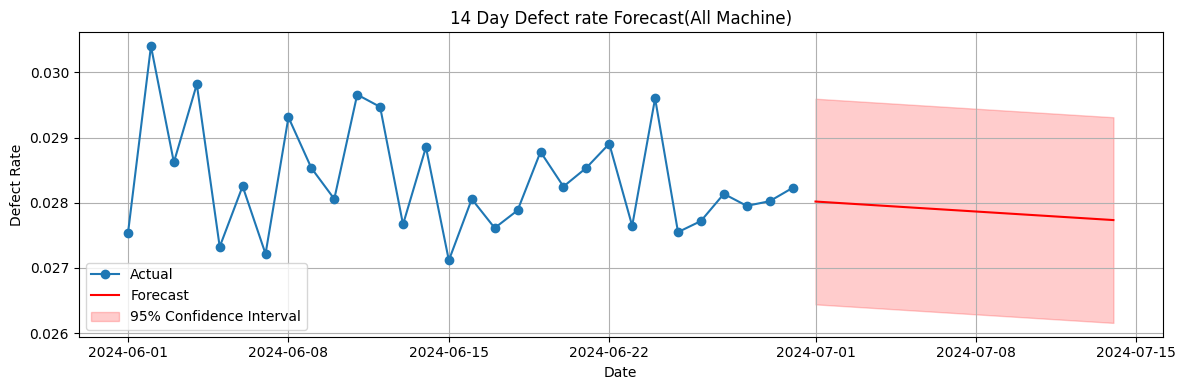

In [ ]:
# Forecast defect rate
df['Defect_rate']=df['Defective_Units']/df['Units_Produced']

daily_defect = df.groupby('Date')[['Defective_Units','Units_Produced']].sum().reset_index()

daily_defect['Defect_rate']=daily_defect['Defective_Units']/daily_defect['Units_Produced']

# Define X1 and y1
X1= np.arange(len(daily_defect)).reshape(-1,1)
y1= daily_defect['Defect_rate'].values # Removed .reshape(-1,1)

# Model - Linear regression
model1= LinearRegression()
model1.fit(X1,y1)

# Prediction for next 14 days
X1_future= np.arange(len(daily_defect),len(daily_defect)+14).reshape(-1,1)
y1_pred= model1.predict(X1_future)

future_dates=[daily_defect['Date'].iloc[-1]+pd.Timedelta(days=i+1) for i in range(14)]

# Plot trends for defect rate (overall)
plt.figure(figsize=(12,4))
plt.plot(daily_defect['Date'],y1,label='Actual', marker='o')
plt.plot(future_dates,y1_pred,label='Forecast',color='red')

# 95% Confidence interval (dynamic)
residuals= y1-model1.predict(X1)
std_error= np.std(residuals)
ci=1.96*std_error

plt.fill_between(future_dates,y1_pred-ci,y1_pred+ci,color='red',alpha=0.2,label='95% Confidence Interval')

plt.title('14 Day Defect rate Forecast(All Machine)')
plt.xlabel('Date')
plt.ylabel('Defect Rate')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Observations and Insights:-
1)

Actions and recommendations:-

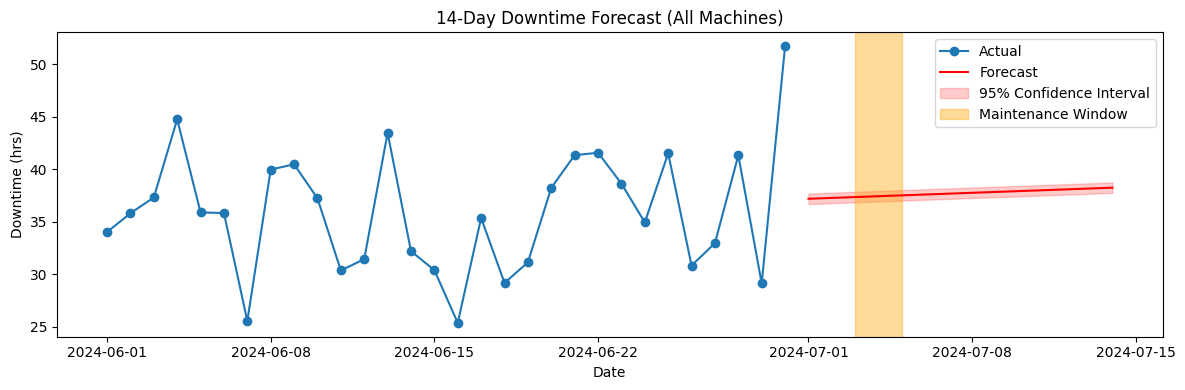

In [ ]:
# DOWNTIME FORECAST (All Machines)
daily_downtime = df.groupby('Date')['Downtime (hrs)'].sum().reset_index()
X2 = np.arange(len(daily_downtime)).reshape(-1, 1)
y2 = daily_downtime['Downtime (hrs)'].values.reshape(-1, 1)
model2 = LinearRegression().fit(X2, y2)
X2_future = np.arange(len(daily_downtime), len(daily_downtime) + 14).reshape(-1,1)
y2_pred = model2.predict(X2_future)
future_dates2 = [daily_downtime['Date'].iloc[-1] + pd.Timedelta(days=i+1) for i in range(14)]

plt.figure(figsize=(12, 4))
plt.plot(daily_downtime['Date'], y2, label='Actual', marker='o')
plt.plot(future_dates2, y2_pred, label='Forecast', color='red')
plt.fill_between(future_dates2, (y2_pred - 0.5).flatten(), (y2_pred + 0.5).flatten(), color='red',alpha=0.2,label='95% Confidence Interval')
plt.axvspan(future_dates2[2], future_dates2[4], color='orange', alpha=0.4, label='Maintenance Window')

plt.title("14-Day Downtime Forecast (All Machines)")
plt.xlabel("Date")
plt.ylabel("Downtime (hrs)")
plt.legend()
plt.tight_layout()
plt.show()

Observations and Insights:- 1)

Actions and recommendations:-

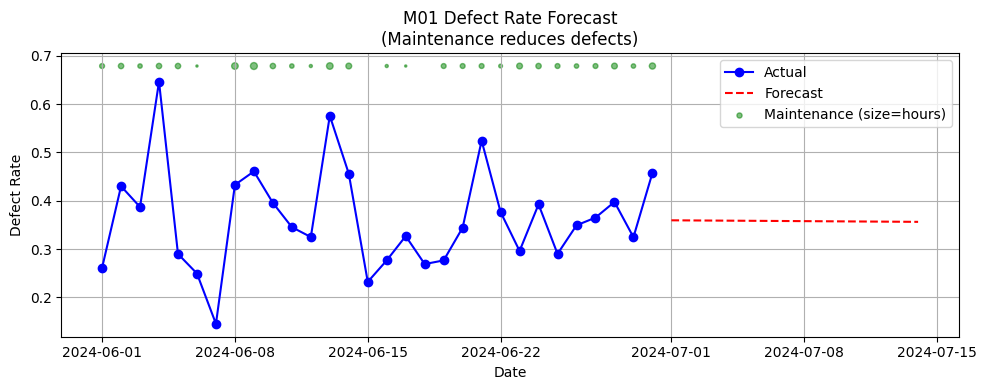

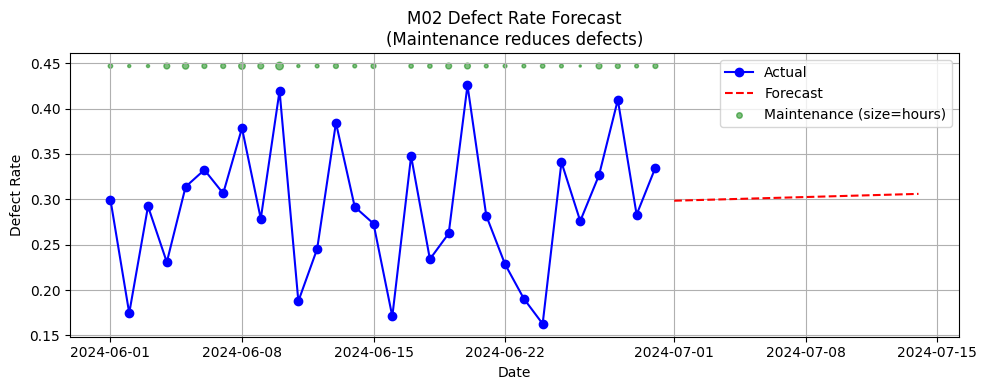

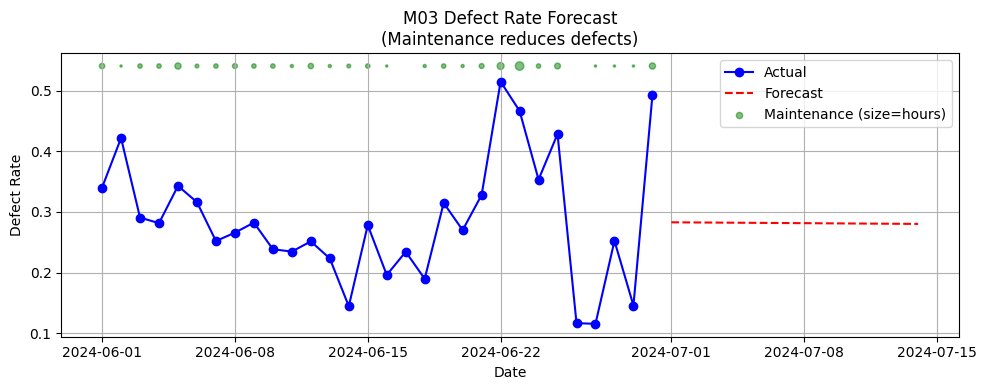

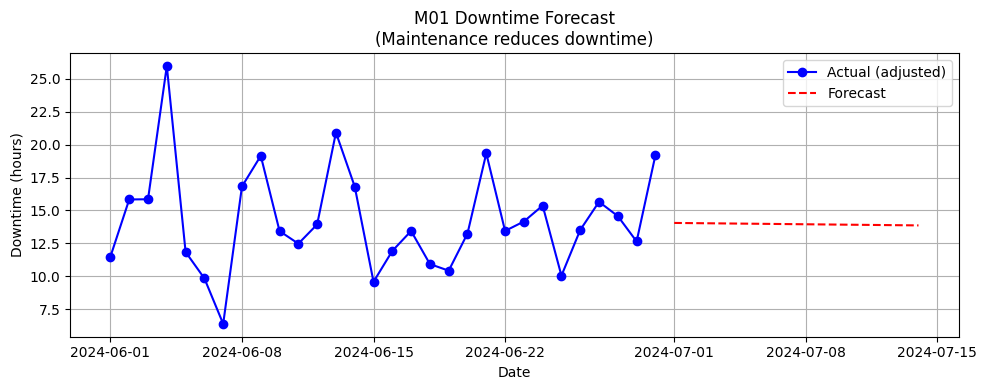

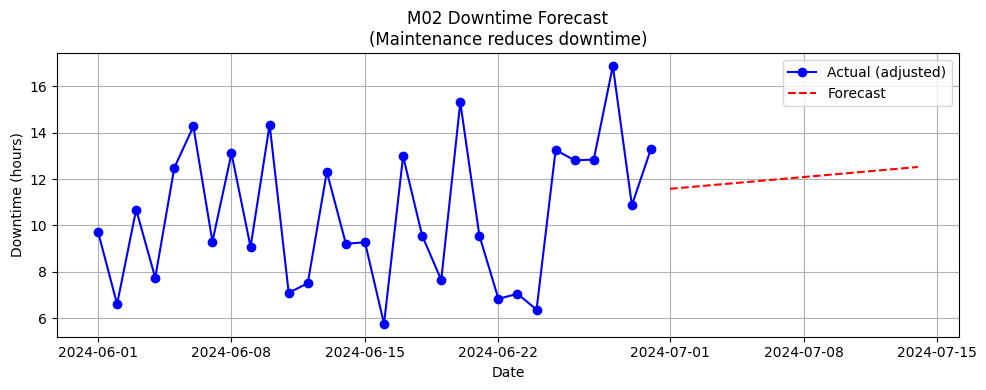

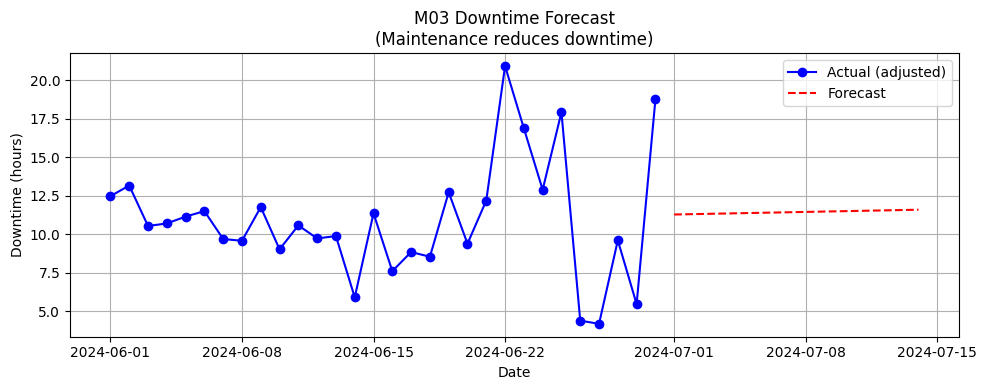

In [ ]:
# 14 days Predictive Analysis for individual Machines
machines = ['M01', 'M02', 'M03']

# DEFECT RATE FORECAST
for machine in machines:
    df_machine = df[df['Machine'] == machine].copy()

    # Calculate defect rate with maintenance adjustment (more hours = lower defects)
    df_machine['Defect_Rate'] = (df_machine['Defective_Units'] / df_machine['Units_Produced'] * (1 - 0.2 * (df_machine['Maintenance_Hours'] / 8)))
    daily_data = df_machine.groupby('Date')[['Defect_Rate', 'Maintenance_Hours']].sum().reset_index()

    if len(daily_data) < 2:
        print(f"Skipping {machine}: Not enough data")
        continue

    # linear forecast
    X = np.arange(len(daily_data)).reshape(-1, 1)
    y = daily_data['Defect_Rate'].values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)

    # 14-day forecast
    future_dates = [daily_data['Date'].iloc[-1] + pd.Timedelta(days=i+1) for i in range(14)]
    X_future = np.arange(len(daily_data), len(daily_data)+14).reshape(-1, 1)
    y_pred = model.predict(X_future)

    # Visualize
    plt.figure(figsize=(10, 4))
    plt.plot(daily_data['Date'], y, 'b-o', label='Actual')
    plt.plot(future_dates, y_pred, 'r--', label='Forecast')

    # Highlight maintenance days
    maint_days = daily_data[daily_data['Maintenance_Hours'] > 0]
    plt.scatter(maint_days['Date'], [y.max()*1.05]*len(maint_days),s=maint_days['Maintenance_Hours']*5, color='green', alpha=0.5,label='Maintenance (size=hours)')
    plt.title(f"{machine} Defect Rate Forecast\n(Maintenance reduces defects)")
    plt.xlabel("Date")
    plt.ylabel("Defect Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# DOWNTIME FORECAST
for machine in machines:
    df_machine = df[df['Machine'] == machine].copy()

    # Adjust downtime based on maintenance (more hours = less downtime)
    df_machine['Downtime_Adj'] = df_machine['Downtime (hrs)'] * \
(1 - 0.3 * (df_machine['Maintenance_Hours'] / 8))

    daily_data = df_machine.groupby('Date')[['Downtime_Adj', 'Maintenance_Hours']].sum().reset_index()

    if len(daily_data) < 2:
        print(f"Skipping {machine}: Not enough data")
        continue

    # Forecast model
    X = np.arange(len(daily_data)).reshape(-1, 1)
    y = daily_data['Downtime_Adj'].values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)

    # 14-day forecast
    future_dates = [daily_data['Date'].iloc[-1] + pd.Timedelta(days=i+1) for i in range(14)]
    X_future = np.arange(len(daily_data), len(daily_data)+14).reshape(-1, 1)
    y_pred = model.predict(X_future)

    # Visualize
    plt.figure(figsize=(10, 4))
    plt.plot(daily_data['Date'], y, 'b-o', label='Actual (adjusted)')
    plt.plot(future_dates, y_pred, 'r--', label='Forecast')

    plt.title(f"{machine} Downtime Forecast\n(Maintenance reduces downtime)")
    plt.xlabel("Date")
    plt.ylabel("Downtime (hours)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Observations and Insights:-

Actions and recommendations:-Based on the forecast, continue to monitor downtime for this machine.
Investigate the reasons for past downtime spikes to help in developing more robust strategies to minimize downtime in the future.
Consider proactive maintenance or adjustments to the schedule to mitigate potential disruptions, especially if the forecast shows an increase

Conclusion:- M01 is showing a potential increase in defect rate despite maintenance, meaning its current maintenance strategy might not be sufficient.

M02 is expected to improve defect rate performance, suggesting its maintenance plan is effective.

M03 is maintenance plan is working effectively—the defect rate is forecasted to decrease steadily in July.

M01 performs best in downtime stability.

M02 and M03 show rising downtime trends, requiring revised maintenance strategies.